# Point 2 - Prediction and Classification Definition

In [1]:
import pandas as pd
import numpy as np

In [3]:
# Load Dataset

df = pd.read_csv("../DATASET/dataset_expandido.csv")

# Definição dos Objetivos de Machine Learning

O dataset Stack Overflow Developer Survey 2024 que no nosso caso é o dataset_expandido, permite a aplicação de problemas de classificação e regressão, devido à diversidade de variáveis disponíveis.

Neste projeto foram definidas duas variáveis target, uma para classificação e outra para regressão, permitindo explorar ambas as abordagens exigidas no enunciado do trabalho.

## Problema de Classificação

Para a componente de classificação foi utilizada a variável `JobSat_Class`. Esta variável foi criada a partir da variavel JobSat, passando de numérica a categórica.

Esta variável representa o nível de satisfação profissional dos developers, dividido em três classes:

- Baixo
- Médio
- Alto

Como o objetivo consiste em prever categorias, este problema é considerado um problema de classificação.
O objetivo principal é classificar developers de acordo com o seu nível de satisfação profissional, utilizando características profissionais, académicas e demográficas presentes no dataset.

In [6]:
df["JobSat_Class"].value_counts()

JobSat_Class
Medio    117506
Alto      33747
Baixo     14184
Name: count, dtype: int64

## Problema de Regressão

Para a componente de regressão foi utilizada a variável `ConvertedCompYearly`, correspondente ao salário anual dos developers.

Esta variável representa um valor contínuo e numérico, sendo adequada para problemas de regressão.
O objetivo consiste em prever o salário anual dos developers com base em características profissionais, tecnológicas e demográficas presentes no dataset.

In [7]:
df["ConvertedCompYearly"].describe()


count    1.654370e+05
mean     7.233331e+04
std      9.821890e+04
min      1.000000e+00
25%      6.500000e+04
50%      6.500000e+04
75%      6.500000e+04
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

# Point 4 - Analysis of the fit time per machine learning model

Foram encontrados 15 ficheiros.
                     Model  Average Time (min)
14                  06_SVM          266.571429
11             14_Stacking            9.660000
13      15_Neural_Networks            4.040000
10    12_Gradient_Boosting            3.850000
5                   07_KNN            3.662500
9              11_AdaBoost            3.566667
7               09_Bagging            1.980000
6        08_Decision_Trees            1.030000
8         10_Random_Forest            0.352667
12              13_XGBoost            0.215278
1   02_Logistic_Regression            0.203847
4           05_Naive_Bayes            0.147917
3      04_Lasso_Regression            0.115617
0     01_Linear_Regression            0.113008
2      03_Ridge_Regression            0.071406


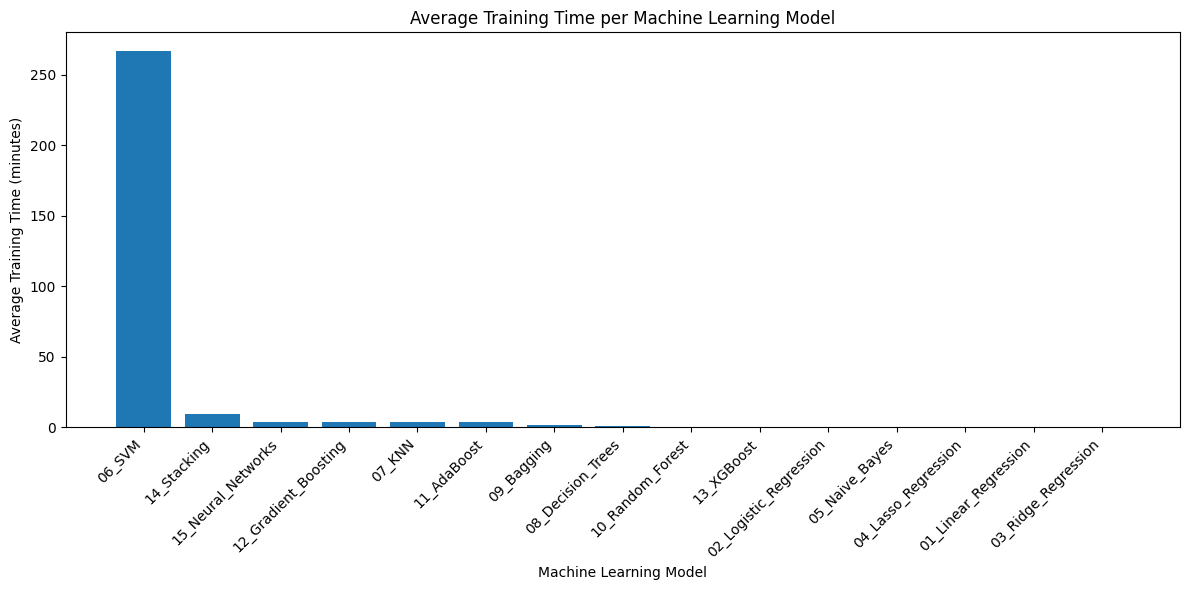

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Definir diretório do projeto (ajusta se necessário)
os.chdir(r"C:\Users\luisr\OneDrive\Ambiente de Trabalho\DataSet_GroupProject\Machine_Learning_Experiments")

# Encontrar todos os CSVs
csv_files = glob.glob("Runs/*.csv")

print(f"Foram encontrados {len(csv_files)} ficheiros.")

# Função para converter duração para minutos
def duration_to_minutes(duration):

    duration = str(duration).strip()

    if duration.endswith("ms"):
        return float(duration[:-2]) / 60000

    elif duration.endswith("min"):
        return float(duration[:-3])

    elif duration.endswith("h"):
        return float(duration[:-1]) * 60

    elif duration.endswith("s"):
        return float(duration[:-1]) / 60

    else:
        return None

# Calcular tempos médios
results = []

for file in csv_files:

    df = pd.read_csv(file)

    model_name = df["Source Name"].iloc[0]
    model_name = model_name.replace(".ipynb", "")

    durations = df["Duration"].apply(duration_to_minutes)

    average_time = durations.mean()

    results.append({
        "Model": model_name,
        "Average Time (min)": average_time
    })

# Criar DataFrame
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Average Time (min)",
    ascending=False
)

# Mostrar tabela
print(results_df)

# Guardar tabela
results_df.to_csv(
    "average_training_times.csv",
    index=False
)

# Gráfico com todos os modelos
plt.figure(figsize=(12,6))

plt.bar(
    results_df["Model"],
    results_df["Average Time (min)"]
)

plt.xticks(rotation=45, ha="right")

plt.xlabel("Machine Learning Model")
plt.ylabel("Average Training Time (minutes)")
plt.title("Average Training Time per Machine Learning Model")

plt.tight_layout()

plt.savefig(
    "average_training_time_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
#Gráfico X - com todos os modelos onde o SVM abafa os outros

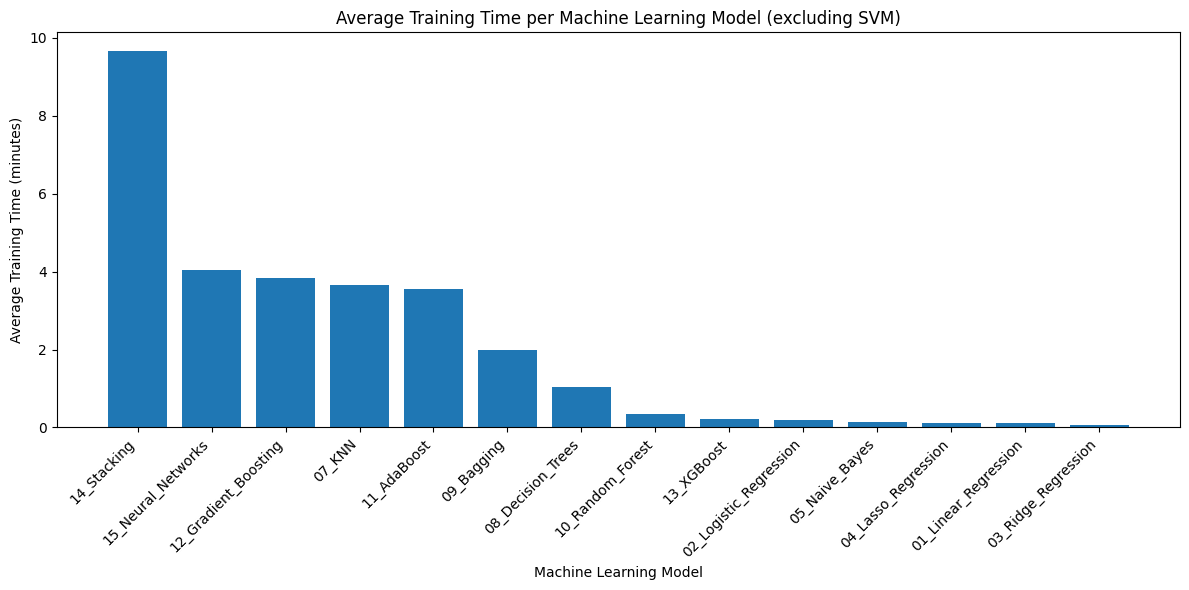

In [13]:
results_no_svm = results_df[
    results_df["Model"] != "06_SVM"
]

plt.figure(figsize=(12,6))

plt.bar(
    results_no_svm["Model"],
    results_no_svm["Average Time (min)"]
)

plt.xticks(rotation=45, ha="right")

plt.xlabel("Machine Learning Model")
plt.ylabel("Average Training Time (minutes)")
plt.title("Average Training Time per Machine Learning Model (excluding SVM)")

plt.tight_layout()

plt.savefig(
    "average_training_time_without_svm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
#Gráfico Y - todos os modelos menos o SVM

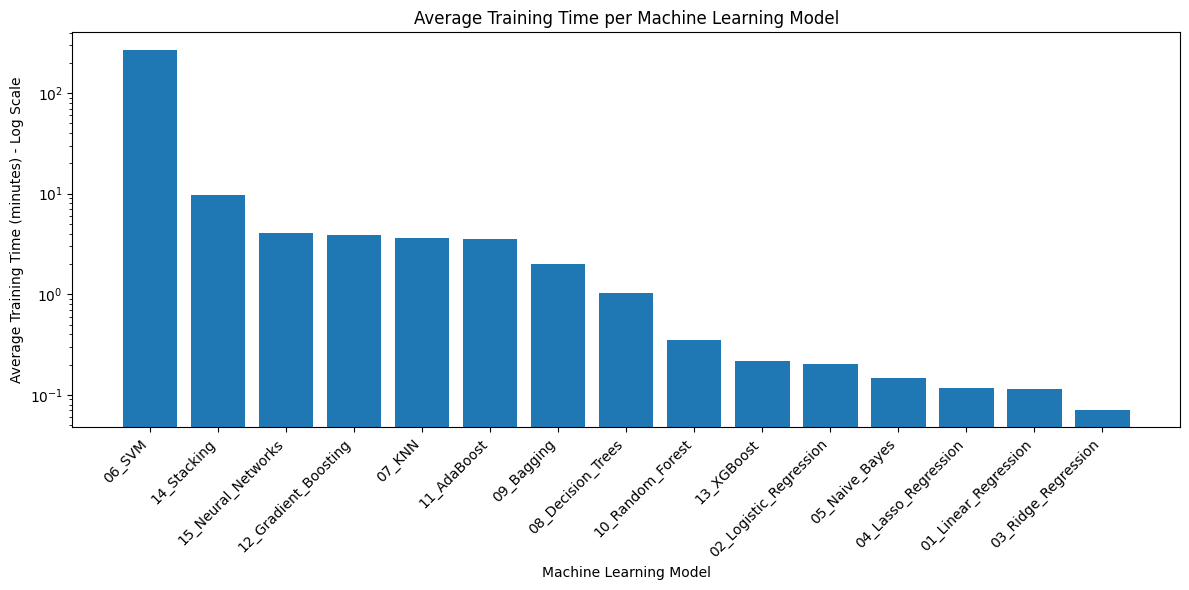

In [14]:
plt.figure(figsize=(12,6))

plt.bar(
    results_df["Model"],
    results_df["Average Time (min)"]
)

plt.yscale("log")

plt.xticks(rotation=45, ha="right")

plt.xlabel("Machine Learning Model")
plt.ylabel("Average Training Time (minutes) - Log Scale")
plt.title("Average Training Time per Machine Learning Model")

plt.tight_layout()

plt.savefig(
    "average_training_time_log_scale.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
#Gráfico Z - todos os modelos mas em escala logaritmica

In [17]:
results_df["Average Time (min)"] = results_df["Average Time (min)"].round(2)

results_df

,Model,Average Time (min)
14,06_SVM,266.57
11,14_Stacking,9.66
13,15_Neural_Networks,4.04
10,12_Gradient_Boosting,3.85
5,07_KNN,3.66
9,11_AdaBoost,3.57
7,09_Bagging,1.98
6,08_Decision_Trees,1.03
8,10_Random_Forest,0.35
12,13_XGBoost,0.22


In [18]:
results_df.to_csv(
    "fit_time_summary.csv",
    index=False
)

### Análise do fit



### Análise do tempo de ajuste por modelo de aprendizagem automática

O tempo de ajuste (fit time) foi analisado para avaliar o custo computacional associado ao treino dos diferentes modelos de aprendizagem automática. A **Figura X** apresenta o tempo médio de treino de todos os modelos numa escala linear. A **Figura Y** apresenta os mesmos resultados após a exclusão do modelo SVM, permitindo uma comparação mais detalhada entre os restantes algoritmos. Por fim, a **Figura Z** apresenta os tempos médios de treino utilizando uma escala logarítmica, facilitando a visualização das diferenças existentes entre modelos com custos computacionais muito distintos.

A análise da **Figura X** demonstra que o modelo **Support Vector Machine (SVM)** apresentou um tempo médio de treino significativamente superior aos restantes algoritmos, atingindo aproximadamente **266,57 minutos**. Este valor é substancialmente superior aos observados nos restantes modelos, tornando difícil a comparação visual quando todos os algoritmos são representados na mesma escala.

Por esse motivo, a **Figura Y** exclui o modelo SVM e permite observar com maior detalhe o comportamento dos restantes algoritmos. Nesta figura verifica-se que o método **Stacking** apresentou o maior tempo médio de treino (**9,66 minutos**), seguido pelas **Redes Neuronais** (**4,04 minutos**), **Gradient Boosting** (**3,85 minutos**), **K-Nearest Neighbors (KNN)** (**3,66 minutos**) e **AdaBoost** (**3,57 minutos**). Estes resultados são consistentes com a maior complexidade computacional destes algoritmos, uma vez que envolvem múltiplos modelos ou processos iterativos de otimização.

Os modelos **Bagging** e **Decision Trees** apresentaram tempos médios intermédios, de aproximadamente **1,98 minutos** e **1,03 minutos**, respetivamente. O algoritmo **Random Forest**, apesar de também pertencer à categoria dos métodos ensemble, registou um tempo médio relativamente reduzido (**0,35 minutos**).

Os menores tempos de treino foram observados nos modelos lineares, nomeadamente **Linear Regression**, **Ridge Regression**, **Lasso Regression** e **Logistic Regression**, todos com tempos médios inferiores a um minuto. Os algoritmos **Naive Bayes** e **XGBoost** também demonstraram uma elevada eficiência computacional.

A **Figura Z**, que utiliza uma escala logarítmica, permite visualizar simultaneamente todos os modelos sem que o valor extremo do SVM comprometa a interpretação dos restantes resultados. Esta representação evidencia de forma mais clara as diferenças de ordem de grandeza existentes entre os algoritmos analisados.

De forma geral, os resultados demonstram que existe um compromisso entre a complexidade dos modelos e o respetivo custo computacional. Embora algoritmos mais complexos possam apresentar vantagens em termos de desempenho preditivo, o seu treino exige normalmente tempos de processamento superiores aos observados nos modelos mais simples.
